# 🚚 Lane One Data — Exploratory Data Analysis (EDA)

This notebook performs a structured EDA on **Lane One (dispatch) data** using the accompanying **Lane One Legend**.

It will:
- Load the Lane One dataset and legend
- Clean and parse the legend
- Classify columns into **categorical**, **numeric**, and **date** groups
- Run EDA for each group (summary stats, missing values, top-k plots, histograms/boxplots, time trends)
- Create derived metrics (e.g., Profit %, key intervals like *Mill Ready → Ship*)
- Save artifacts (plots and CSVs) to an `eda_lane_output/` folder

> Uses only `pandas` and `matplotlib` (no seaborn). Each chart is a single-plot figure.


In [7]:
# %% Setup paths & imports

# === Config: set your paths here ===
LANE_DATA_CSV   = r"/Users/nitaishah/Desktop/STAT-683/Data/Data_Split/Lane_One/Lane One Data.csv"      # <-- change if needed
LANE_LEGEND_CSV = r"/Users/nitaishah/Desktop/STAT-683/Data/Data_Split/Lane_One/Lane One Legend.csv"     # <-- change if needed

# Output directory
from pathlib import Path
OUTDIR = Path("./eda_lane_output")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True
})

print("Output directory:", OUTDIR.resolve())


Output directory: /Users/nitaishah/Desktop/STAT-683/EDA/Lane_One/eda_lane_output


In [8]:
# %% Load Lane One data & legend

# === Load data ===
lane_df = pd.read_csv(LANE_DATA_CSV)
legend_df_raw = pd.read_csv(LANE_LEGEND_CSV)

print("Lane One Data shape:", lane_df.shape)
print("Legend raw shape:", legend_df_raw.shape)
display(lane_df.head(3))
display(legend_df_raw.head(5))


Lane One Data shape: (8167, 19)
Legend raw shape: (20, 2)


,Pro #,Type of Shipment,Actual Dispatcher,Created Date,Ship Date,Delivered Date,Pickup City,Pickup State,Pickup Zip,Consignee City,Consignee State,Consignee Zip,Carrier Name,Miles/Class,LOT Revenue,LOT Carrier Expense,LOT Gross Profit,LOT Profit %,Mill Ready Dt
0,33769,F,STANVAN,2024-12-13,2025-01-03,2025-01-06,GLOSTER,MS,39638.0,KENNARD,TX,75847.0,FBN TRANSPORTATION L,309.0,1055.31,1000.0,55.31,5.2,2025-12-11 00:00:00
1,33797,F,ALEXMENA,2024-12-13,2025-01-06,2025-01-07,HOLDEN,LA,70744.0,TUSCUMBIA,AL,35674.0,COFFEY TRUCKING LLC,423.0,1195.00,1100.0,95.00,7.9,2025-12-13 00:00:00
2,33830,F,STANVAN,2024-12-16,2025-01-02,2025-01-03,CHOPIN,LA,71447.0,BRYAN,TX,77807.0,ZUNIGA S HOTSHOT LLC,263.0,1000.00,900.0,100.00,10.0,2025-12-16 00:00:00


,Lane One Legend:,Unnamed: 1
0,NaN,NaN
1,Pro #,"Unique, per load reference number assigned by ..."
2,Type of Shipment,"F = Flatbed, V = Van, LTL = Partial / Hotshot...."
3,Actual Dispatcher,Dispatcher that covered the load.
4,Created Date,This is the date the load came over from Lumbe...


In [9]:
# %% Clean & parse legend

# === Clean & parse legend ===
# Keep first two columns: Column name + Description
legend_df = legend_df_raw.iloc[:, :2].copy()
legend_df.columns = ["Column", "Description"]
legend_df = legend_df.dropna(subset=["Column"]).reset_index(drop=True)

# Normalize for matching
legend_df["Column_norm"] = legend_df["Column"].astype(str).str.strip().str.lower()

display(legend_df.head(10))

# Save cleaned legend
legend_df[["Column","Description"]].to_csv(OUTDIR / "LaneOne_Legend_Cleaned.csv", index=False, encoding="utf-8-sig")
print("Saved:", OUTDIR / "LaneOne_Legend_Cleaned.csv")


,Column,Description,Column_norm
0,Pro #,"Unique, per load reference number assigned by ...",pro #
1,Type of Shipment,"F = Flatbed, V = Van, LTL = Partial / Hotshot....",type of shipment
2,Actual Dispatcher,Dispatcher that covered the load.,actual dispatcher
3,Created Date,This is the date the load came over from Lumbe...,created date
4,Ship Date,Date the load picked up.,ship date
5,Pickup City,NaN,pickup city
6,Pickup State,NaN,pickup state
7,Pickup Zip,NaN,pickup zip
8,Consignee City,Consignee = Delivery,consignee city
9,Consignee State,Consignee = Delivery,consignee state


Saved: eda_lane_output/LaneOne_Legend_Cleaned.csv


In [10]:
# %% Classify columns

# === Column classification (categorical / numeric / date) ===
categorical, numeric, date_cols = [], [], []

def get_desc(col):
    key = col.strip().lower()
    m = legend_df.loc[legend_df["Column_norm"] == key, "Description"].values
    if len(m) > 0 and isinstance(m[0], str):
        return m[0]
    return ""

for col in lane_df.columns:
    desc_text = get_desc(col).lower()

    if "date" in desc_text:
        date_cols.append(col)
    elif any(word in desc_text for word in ["name", "city", "state", "zip", "description", "address", "dispatcher", "shipment", "mill"]):
        categorical.append(col)
    elif str(lane_df[col].dtype) in ["float64", "int64"]:
        numeric.append(col)
    else:
        categorical.append(col)

print("Categorical ({}):".format(len(categorical)), categorical)
print("Numeric ({}):".format(len(numeric)), numeric)
print("Date ({}):".format(len(date_cols)), date_cols)

pd.DataFrame({"categorical": pd.Series(categorical)}).to_csv(OUTDIR / "LaneOne_Categorical_Columns.csv", index=False)
pd.DataFrame({"numeric": pd.Series(numeric)}).to_csv(OUTDIR / "LaneOne_Numeric_Columns.csv", index=False)
pd.DataFrame({"date": pd.Series(date_cols)}).to_csv(OUTDIR / "LaneOne_Date_Columns.csv", index=False)
print("Saved column lists to:", OUTDIR)


Categorical (8): ['Type of Shipment', 'Actual Dispatcher', 'Delivered Date', 'Pickup City', 'Pickup State', 'Consignee City', 'Consignee State', 'Carrier Name']
Numeric (8): ['Pro #', 'Pickup Zip', 'Consignee Zip', 'Miles/Class', 'LOT Revenue', 'LOT Carrier Expense', 'LOT Gross Profit', 'LOT Profit %']
Date (3): ['Created Date', 'Ship Date', 'Mill Ready Dt']
Saved column lists to: eda_lane_output


In [11]:
# %% Info & missing values

# === Info & missing values ===
info_text = []
info_text.append(f"Rows: {lane_df.shape[0]}, Columns: {lane_df.shape[1]}")
dtype_counts = lane_df.dtypes.astype(str).value_counts().to_dict()
info_text.append(f"Dtypes: {dtype_counts}")
print("\n".join(info_text))

missing = lane_df.isna().sum().sort_values(ascending=False)
display(missing.head(20))
missing.to_csv(OUTDIR / "LaneOne_Missing_Values.csv", header=["missing_count"])
print("Saved:", OUTDIR / "LaneOne_Missing_Values.csv")


Rows: 8167, Columns: 19
Dtypes: {'object': 11, 'float64': 7, 'int64': 1}


Miles/Class            108
Mill Ready Dt           56
Consignee Zip           50
Pickup Zip              29
Actual Dispatcher       27
Pickup City             27
Pickup State            27
Consignee State         27
Carrier Name            27
Delivered Date          11
LOT Revenue              0
LOT Profit %             0
LOT Gross Profit         0
LOT Carrier Expense      0
Pro #                    0
Type of Shipment         0
Ship Date                0
Created Date             0
Consignee City           0
dtype: int64

Saved: eda_lane_output/LaneOne_Missing_Values.csv


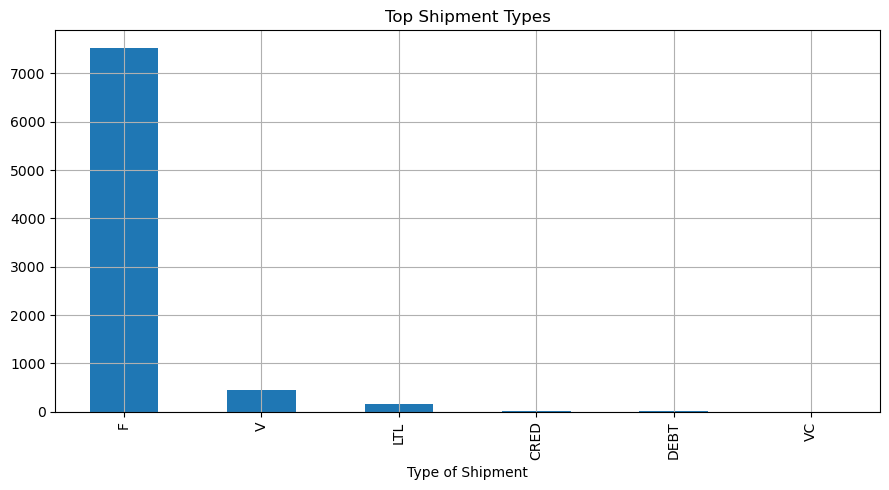

Saved plot: eda_lane_output/Type of Shipment_top10.png


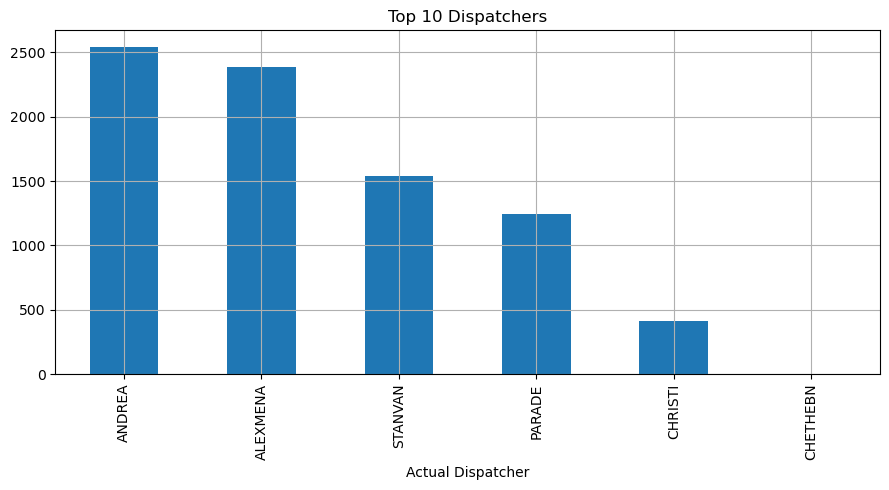

Saved plot: eda_lane_output/Actual Dispatcher_top10.png


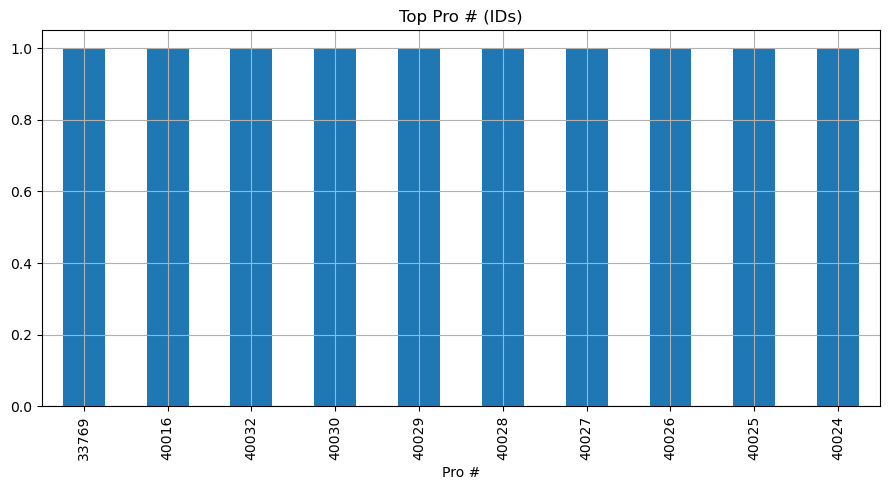

Saved plot: eda_lane_output/Pro #_top10.png
Saved frequency tables for all categorical columns.


In [12]:
# %% Categorical EDA

# === Categorical EDA ===
def top_k_bar(series, title, k=10, fname="plot.png"):
    vc = series.value_counts().head(k)
    plt.figure()
    vc.plot(kind="bar")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTDIR / fname, dpi=150)
    plt.show()

def plot_if_exists(df, col, title, k=10):
    if col in df.columns:
        top_k_bar(df[col].dropna(), title=title, k=k, fname=f"{col}_top{k}.png")
        print("Saved plot:", OUTDIR / f"{col}_top{k}.png")

# Common Lane One categoricals
for col, title in [
    ("Type of Shipment", "Top Shipment Types"),
    ("Actual Dispatcher", "Top 10 Dispatchers"),
    ("Pro #", "Top Pro # (IDs)"),
]:
    plot_if_exists(lane_df, col, title, 10)

# Save frequency tables for all categorical columns
for col in categorical:
    freq = lane_df[col].value_counts(dropna=False)
    freq.to_csv(OUTDIR / f"freq_{col}.csv", header=["count"])
print("Saved frequency tables for all categorical columns.")


,count,mean,std,min,25%,50%,75%,max
Pro #,8167.0,38537.791968,2570.812664,33769.0,36295.5,38546.0,40789.50,43024.0
Pickup Zip,8138.0,57359.106783,18795.509864,7863.0,38834.0,71019.0,74745.00,83845.0
Consignee Zip,8117.0,60361.373167,19324.294225,7863.0,38052.0,75061.0,77032.00,94085.0
Miles/Class,8059.0,308.478099,203.559692,0.0,165.0,269.0,421.00,2051.0
LOT Revenue,8167.0,1222.592363,571.675354,-475.0,830.0,1100.0,1543.69,4900.0
LOT Carrier Expense,8167.0,1066.654808,501.081803,0.0,725.0,950.0,1350.00,4600.0
LOT Gross Profit,8167.0,156.335052,109.779278,-775.0,100.0,150.0,205.00,1300.0
LOT Profit %,8167.0,12.302939,9.744523,-400.0,10.7,14.3,15.20,100.0


Saved: eda_lane_output/LaneOne_Numeric_Describe.csv


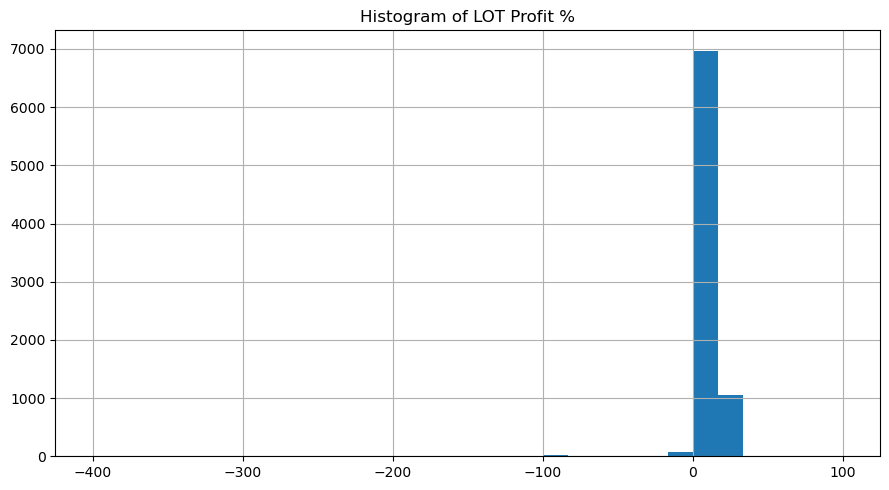

Saved plot: eda_lane_output/hist_LOT Profit %.png


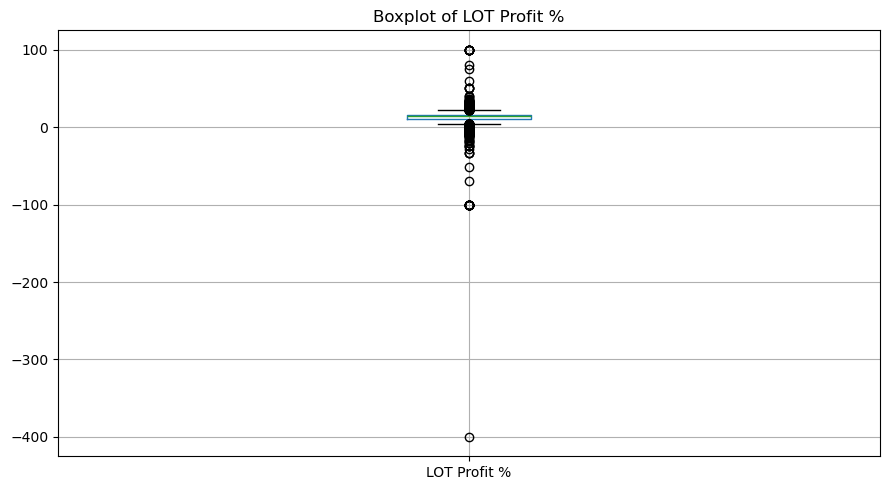

Saved plot: eda_lane_output/box_LOT Profit %.png


,Pro #,Pickup Zip,Consignee Zip,Miles/Class,LOT Revenue,LOT Carrier Expense,LOT Gross Profit,LOT Profit %
Pro #,1.000000,-0.004168,-0.000093,-0.004775,0.062498,0.059340,0.052618,-0.001442
Pickup Zip,-0.004168,1.000000,0.706088,-0.061554,-0.105522,-0.112424,-0.035330,0.012589
Consignee Zip,-0.000093,0.706088,1.000000,-0.004365,0.009314,0.005117,0.023639,-0.005174
Miles/Class,-0.004775,-0.061554,-0.004365,1.000000,0.927301,0.918587,0.634648,0.062431
LOT Revenue,0.062498,-0.105522,0.009314,0.927301,1.000000,0.986862,0.702322,0.124135
LOT Carrier Expense,0.059340,-0.112424,0.005117,0.918587,0.986862,1.000000,0.582267,0.023233
LOT Gross Profit,0.052618,-0.035330,0.023639,0.634648,0.702322,0.582267,1.000000,0.530241
LOT Profit %,-0.001442,0.012589,-0.005174,0.062431,0.124135,0.023233,0.530241,1.000000


Saved: eda_lane_output/LaneOne_Numeric_Correlation.csv


In [13]:
# %% Numeric EDA

# === Numeric EDA ===
desc = lane_df[numeric].describe().T if len(numeric) > 0 else pd.DataFrame()
if not desc.empty:
    desc.to_csv(OUTDIR / "LaneOne_Numeric_Describe.csv", encoding="utf-8-sig")
    display(desc.head(10))
    print("Saved:", OUTDIR / "LaneOne_Numeric_Describe.csv")

def hist_if_exists(df, col, bins=30):
    if col in df.columns:
        plt.figure()
        df[col].dropna().hist(bins=bins)
        plt.title(f"Histogram of {col}")
        plt.tight_layout()
        plt.savefig(OUTDIR / f"hist_{col}.png", dpi=150)
        plt.show()
        print("Saved plot:", OUTDIR / f"hist_{col}.png")

def box_if_exists(df, col):
    if col in df.columns:
        plt.figure()
        df[[col]].boxplot()
        plt.title(f"Boxplot of {col}")
        plt.tight_layout()
        plt.savefig(OUTDIR / f"box_{col}.png", dpi=150)
        plt.show()
        print("Saved plot:", OUTDIR / f"box_{col}.png")

# Likely numeric in Lane One
for col in ["LOT Profit %"]:
    hist_if_exists(lane_df, col)
    box_if_exists(lane_df, col)

# Correlations
if len(numeric) > 1:
    corr = lane_df[numeric].corr(numeric_only=True)
    corr.to_csv(OUTDIR / "LaneOne_Numeric_Correlation.csv", encoding="utf-8-sig")
    display(corr)
    print("Saved:", OUTDIR / "LaneOne_Numeric_Correlation.csv")


LOT Profit % stats saved: eda_lane_output/LOT_Profit_Percent_Describe.csv


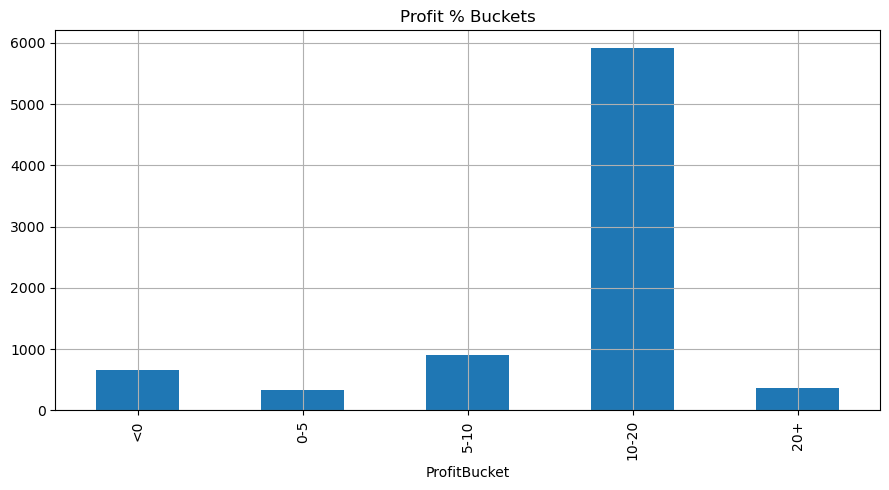

Saved plot: eda_lane_output/bar_ProfitBuckets.png
Saved: eda_lane_output/LaneOne_Data_with_Derived.csv


In [14]:
# %% Derived metrics

# === Derived metrics ===
# Profit % distribution summary
if "LOT Profit %" in lane_df.columns:
    prof_desc = lane_df["LOT Profit %"].describe()
    prof_desc.to_csv(OUTDIR / "LOT_Profit_Percent_Describe.csv", header=["value"])
    print("LOT Profit % stats saved:", OUTDIR / "LOT_Profit_Percent_Describe.csv")

    # Profit % buckets
    bins = [-np.inf, 0, 5, 10, 20, np.inf]
    labels = ["<0", "0-5", "5-10", "10-20", "20+"]
    lane_df["ProfitBucket"] = pd.cut(lane_df["LOT Profit %"], bins=bins, labels=labels)
    bucket_freq = lane_df["ProfitBucket"].value_counts().sort_index()
    bucket_freq.to_csv(OUTDIR / "ProfitBuckets.csv", header=["count"])
    plt.figure()
    bucket_freq.plot(kind="bar")
    plt.title("Profit % Buckets")
    plt.tight_layout()
    plt.savefig(OUTDIR / "bar_ProfitBuckets.png", dpi=150)
    plt.show()
    print("Saved plot:", OUTDIR / "bar_ProfitBuckets.png")

# Save with derived fields
lane_df.to_csv(OUTDIR / "LaneOne_Data_with_Derived.csv", index=False, encoding="utf-8-sig")
print("Saved:", OUTDIR / "LaneOne_Data_with_Derived.csv")


,column,min,max,missing
0,Created Date,2024-12-13,2025-08-29,0
1,Ship Date,2025-01-02,2025-08-29,0
2,Mill Ready Dt,2025-01-01,2025-12-31,67


Saved: eda_lane_output/LaneOne_Date_Coverage.csv


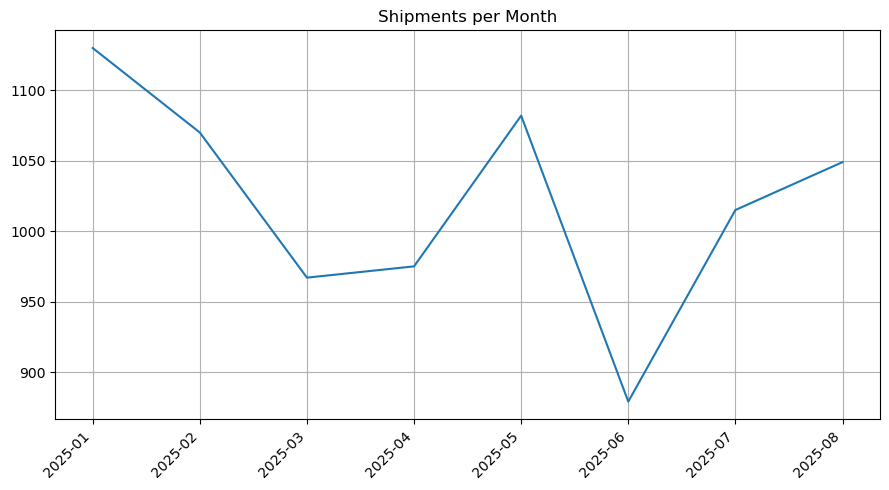

Saved: eda_lane_output/line_Shipments_per_Month.png


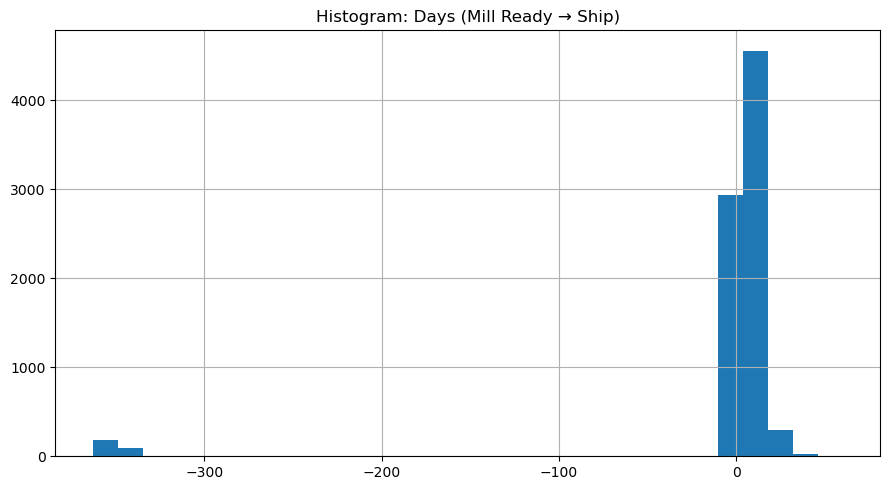

Saved: eda_lane_output/hist_Days_MillReady_to_Ship.png


In [15]:
# %% Dates & time-series analysis

# === Dates & time-based analysis ===
# Expected date-like columns (also pulled from legend classification)
date_like_cols = set(date_cols) | set([
    "Created Date", "Ship Date", "Mill Ready Dt"
])

# Convert if present
for col in list(date_like_cols):
    if col in lane_df.columns:
        lane_df[col] = pd.to_datetime(lane_df[col], errors="coerce")

# Date coverage
coverage = []
for col in [c for c in date_like_cols if c in lane_df.columns]:
    coverage.append({
        "column": col,
        "min": lane_df[col].min(),
        "max": lane_df[col].max(),
        "missing": int(lane_df[col].isna().sum())
    })
cov_df = pd.DataFrame(coverage)
if not cov_df.empty:
    cov_df.to_csv(OUTDIR / "LaneOne_Date_Coverage.csv", index=False, encoding="utf-8-sig")
    display(cov_df)
    print("Saved:", OUTDIR / "LaneOne_Date_Coverage.csv")

# Monthly shipment counts (using Ship Date if available)
if "Ship Date" in lane_df.columns:
    monthly = lane_df["Ship Date"].dt.to_period("M").value_counts().sort_index()
    monthly = monthly.rename_axis("month").reset_index(name="count")
    monthly.to_csv(OUTDIR / "LaneOne_ShipDate_monthly_counts.csv", index=False, encoding="utf-8-sig")
    plt.figure()
    plt.plot(monthly["month"].astype(str), monthly["count"])
    plt.title("Shipments per Month")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTDIR / "line_Shipments_per_Month.png", dpi=150)
    plt.show()
    print("Saved:", OUTDIR / "line_Shipments_per_Month.png")

# Lead time: Mill Ready -> Ship
if all(c in lane_df.columns for c in ["Mill Ready Dt", "Ship Date"]):
    valid = lane_df.dropna(subset=["Mill Ready Dt", "Ship Date"]).copy()
    valid["Days_MillReady_to_Ship"] = (valid["Ship Date"] - valid["Mill Ready Dt"]).dt.days
    valid["Days_MillReady_to_Ship"].to_csv(OUTDIR / "Days_MillReady_to_Ship.csv", index=False, header=["days"])
    plt.figure()
    valid["Days_MillReady_to_Ship"].dropna().hist(bins=30)
    plt.title("Histogram: Days (Mill Ready → Ship)")
    plt.tight_layout()
    plt.savefig(OUTDIR / "hist_Days_MillReady_to_Ship.png", dpi=150)
    plt.show()
    print("Saved:", OUTDIR / "hist_Days_MillReady_to_Ship.png")


In [16]:
# %% Summary report & wrap-up

# === Summary report ===
summary = {
    "rows": lane_df.shape[0],
    "columns": lane_df.shape[1],
    "n_categorical": len(categorical),
    "n_numeric": len(numeric),
    "n_date": len(date_cols),
    "missing_any": int(lane_df.isna().any(axis=1).sum()),
    "missing_total_cells": int(lane_df.isna().sum().sum())
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUTDIR / "EDA_Summary_LaneOne.csv", index=False, encoding="utf-8-sig")
display(summary_df)
print("Saved:", OUTDIR / "EDA_Summary_LaneOne.csv")
print("\nAll outputs written to:", OUTDIR.resolve())


,rows,columns,n_categorical,n_numeric,n_date,missing_any,missing_total_cells
0,8167,20,8,8,3,156,400


Saved: eda_lane_output/EDA_Summary_LaneOne.csv

All outputs written to: /Users/nitaishah/Desktop/STAT-683/EDA/Lane_One/eda_lane_output
